## 6. Métodos de Taylor e Runge-Kutta para EDOs de 1ª ordem

Consideremos o Problema de Valor Inicial (PVI) descrito por
$$\begin{cases}
   y' = f(x,y) \\
   y(x_0)=y_0
  \end{cases}$$

Supondo que a solução $y(x)$ do PVI possui todas as derivadas contínuas no intervalo $[a,b]$ que contém os pontos de discretização $x_0$, $x_1$, ..., $x_n$, o desenvolvimento em série de Taylor da função $y(x)$ em torno do ponto $x_n$ é dado por

$$ y(x) = y(x_n) + y'(x_n)(x−x_n) + y''(x_n)\frac{(x-x_n)^2}{2!}+...$$
$$...+y^{(p)}(x_n)\frac{(x-x_n)^p}{p!}+y^{(p+1)}(\xi)\frac{(x-x_n)^{p+1}}{(p+1)!}$$

com $x_n<\xi<x$.

Tomando $x = x_n + h$, denotado por $x_{n+1}$, temos $h = x_{n+1} − x_n$ e:

$$ y(x) = y(x_n) + y'(x_n)h + y''(x_n)\frac{h^2}{2!}+...$$
$$...+y^{(p)}(x_n)\frac{h^p}{p!}+y^{(p+1)}(\xi)\frac{h^{p+1}}{(p+1)!}$$

Se truncarmos a série de Taylor no p-ésimo termo, temos a **aproximação**

$$ y(x) \approx y(x_n) + y'(x_n)h + y''(x_n)\frac{h^2}{2!}+...+y^{(p)}(x_n)\frac{h^p}{p!}$$

com um **erro de truncamento** dado pelo termo seguinte da série de Taylor

$$e(x_n)=y^{(p+1)}(\xi)\frac{h^{p+1}}{(p+1)!}$$

Se a função $y(x)$ possui a derivada de ordem $(p + 1)$ contínua no intervalo $[a,b]$, então existe $M = \max \left\{ \left|y^{(p+1)}(x)\right|, x \in [a,b] \right\}$, e temos uma estimativa para o erro dada por um limitante superior, de ordem $(p + 1)$, como segue:

$$ |E| \leq \frac{h^{p+1}}{(p+1)!}M$$

Assim, usando a série de Taylor, podemos calcular aproximações para $y(x_{n+1})$ da seguinte forma:

$$ y(x_{n+1}) \approx y_n + y'_nh + y''_n\frac{h^2}{2!}+...+y^{(p)}_n\frac{h^p}{p!}$$

onde, pela regra da cadeia (lembrando que $y' = f(x,y)$),

$$ y'_n = f(x_n, y_n)$$

$$ y''_n = f_x(x_n, y_n) + f_y(x_n, y_n)\,y'_n$$

$$y'''_n = f_{xx}(x_n, y_n) + 2f_{xy}(x_n, y_n)f(x_n, y_n) + f^2(x_n, y_n)f_{yy}(x_n, y_n)+$$
$$+ f_x(x_n, y_n)f_y(x_n,y_n) + f_y^2(x_n, y_n)f(x_n, y_n)$$

$$\vdots$$

(Fonte: [Arenales e Darezzo, 2016](https://integrada.minhabiblioteca.com.br/reader/books/9788522112821/pageid/273))

O método de Euler, visto no [Notebook 5](../Notebook%2005%20-%20M%C3%A9todo%20de%20Euler%20para%20EDOs%20de%201%C2%AA%20ordem/05_metodo_de_euler.ipynb), é exatamente o caso $p=1$ dessa fórmula: $y_{n+1} = y_n + h f(x_n,y_n)$. Tomando $p$ maior, ganhamos ordem de precisão — mas o preço é ter que calcular as derivadas parciais de $f$, que crescem rapidamente em complexidade. Os **métodos de Runge-Kutta**, na segunda parte deste notebook, resolvem exatamente esse problema: atingem a mesma ordem de precisão do método de Taylor **sem exigir nenhuma derivada de $f$**, usando em seu lugar avaliações extras de $f$ em pontos auxiliares.

### 6.1 Método de Taylor de ordem $p=2$

Truncando o desenvolvimento da série de Taylor em $p=2$, temos:

$$
y_{n+1} \approx y_n+h y_n^{\prime}+\frac{h^2}{2!} y_n^{\prime \prime}
$$

em que

$$
y_n^{\prime}=f\left(x_n, y_n\right) \quad \text { e } \quad y_n^{\prime \prime}=f_x\left(x_n, y_n\right)+f_y\left(x_n, y_n\right) y_n^{\prime}
$$

Assim,

$$
y_{n+1} \approx y_n+h f\left(x_n, y_n\right)+\frac{h^2}{2}\left(f_x\left(x_n, y_n\right)+f_y\left(x_n, y_n\right) f\left(x_n, y_n\right)\right)
$$


In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (4, 3)

In [2]:
def tabela_erro(xi, yi, y_exata, nome="y_i"):
    """Imprime a tabela i, x_i, aproximação, valor exato e erro absoluto."""
    print(f"{'i':>3} {'x_i':>10} {nome:>14} {'y(x_i)':>12} {'Erro':>12}")
    print("-" * 56)
    for i in range(len(xi)):
        erro = abs(y_exata[i] - yi[i])
        print(f"{i:3d} {xi[i]:10.4f} {yi[i]:14.6f} {y_exata[i]:12.6f} {erro:12.4e}")

**Exemplo 6.1:** ([Arenales e Darezzo, 2016](https://integrada.minhabiblioteca.com.br/reader/books/9788522112821/pageid/279)) Use o método de Taylor de ordem 2 para integrar numericamente a equação:

$$ \begin{cases}
   \frac{dy}{dx} = x-y+2 \\
    y(0)=2
    \end{cases}$$

de $x = 0$ a $x = 1$ com $N = 5$ subintervalos. Compare os valores e plote o resultado considerando a solução exata $y(x)=e^{-x} + x + 1$.

*Solução:*

Precisamos usar a fórmula de recorrência

$$ y_{n+1} \approx y_n + y'_nh + y''_n\frac{h^2}{2!} $$

em que

$$ y' = x - y + 2 $$

$$ y'' = 1-y' = 1-(x-y+2) = -x+y-1$$

então

$$ y_{n+1} \approx y_n + (x_n - y_n + 2)h + (-x_n+y_n-1) \frac{h^2}{2!} $$

Substituindo $h = 0,2$ na fórmula de recorrência, obtemos:
$$y_{n+1} = 0,18\, x_n + 0,82\, y_n + 0,38.$$

Essa fórmula numérica é válida **apenas para $h=0,2$**; para qualquer outro passo seria preciso refazer a substituição manualmente. Mais adiante repetimos o exemplo obtendo a fórmula de forma automática com SymPy, para qualquer $h$.

In [3]:
x0 = 0
xn = 1
N = 5

xi = np.linspace(x0, xn, N+1)
yi = np.zeros(len(xi))
print(xi)

[0.  0.2 0.4 0.6 0.8 1. ]


In [4]:
yi[0] = 2
y_exata = np.exp(-xi) + xi + 1

# calcula a solução aproximada
for i in range(N):
    yi[i+1] = 0.18*xi[i] + 0.82*yi[i] + 0.38

tabela_erro(xi, yi, y_exata)

  i        x_i            y_i       y(x_i)         Erro
--------------------------------------------------------
  0     0.0000       2.000000     2.000000   0.0000e+00
  1     0.2000       2.020000     2.018731   1.2692e-03
  2     0.4000       2.072400     2.070320   2.0800e-03
  3     0.6000       2.151368     2.148812   2.5564e-03
  4     0.8000       2.252122     2.249329   2.7928e-03
  5     1.0000       2.370740     2.367879   2.8604e-03


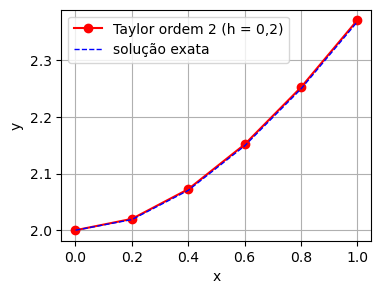

In [5]:
plt.plot(xi, yi, 'ro-', label="Taylor ordem 2 (h = 0,2)")
plt.plot(xi, y_exata, 'b--', lw=1, label="solução exata")
plt.legend()
plt.grid()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

Agora vamos repetir esse mesmo exemplo, mas obtendo a fórmula de recorrência de forma simbólica com SymPy, assim ela vale para qualquer $h$, sem repetir a conta à mão.

In [6]:
def taylor2_formula(dy, var, y):
    """Deriva simbolicamente a fórmula de recorrência do método de Taylor
    de ordem 2 para a EDO y' = dy, em que dy é uma expressão SymPy em
    `var` e `y(var)`. Retorna uma expressão em `var`, `y(var)` e no
    símbolo `h` (o passo ainda não é substituído).
    """
    h = sp.Symbol('h')
    d2y = sp.diff(dy, var).subs(sp.diff(y(var), var), dy)
    return y(var) + dy*h + d2y*h**2/2

In [7]:
# Dados
x, h = sp.symbols('x h')
y = sp.Function('y')

# entrando com a função y'
dy = x - y(x) + 2

f_sym = taylor2_formula(dy, x, y)
f_sym_h02 = sp.simplify(f_sym.subs(h, 0.2))
display(f_sym_h02)   # deve coincidir com a fórmula obtida à mão acima

0.18*x + 0.82*y(x) + 0.38

mesma sequência obtida à mão? True


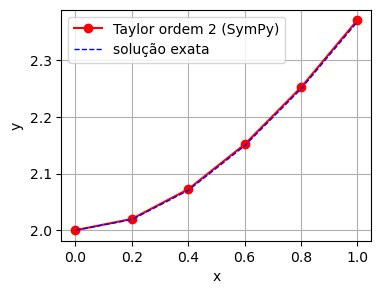

In [8]:
# converte para fórmula numérica e recalcula
f_num = sp.lambdify((x, y(x)), f_sym_h02, 'numpy')

yi2 = np.zeros(len(xi))
yi2[0] = 2
for i in range(N):
    yi2[i+1] = f_num(xi[i], yi2[i])

print("mesma sequência obtida à mão?", np.allclose(yi2, yi))

plt.plot(xi, yi2, 'ro-', label="Taylor ordem 2 (SymPy)")
plt.plot(xi, y_exata, 'b--', lw=1, label="solução exata")
plt.legend()
plt.grid()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

#### Atividade 6.1

Refaça o Exemplo 6.1 com $N=10$ (isto é, $h=0,1$) usando `taylor2_formula`. Monte a tabela de erros e compare o erro final ($x=1$) com o obtido para $h=0,2$. O erro caiu aproximadamente à quarta parte, como esperado de um método de ordem 2?

#### 6.1.1 Generalizando: Taylor de ordem $p$ qualquer

A mesma ideia se generaliza para qualquer ordem $p$: basta derivar $y'=f(x,y)$ sucessivamente pela regra da cadeia, sempre substituindo $\frac{dy}{dx}$ por $f(x,y)$, e somar os termos até $h^p/p!$. Com SymPy isso é só um laço.

In [9]:
def taylor_formula(dy, var, y, p):
    """Deriva simbolicamente a fórmula de recorrência do método de Taylor
    de ordem p para a EDO y' = dy (expressão SymPy em `var` e `y(var)`).
    Retorna uma expressão em `var`, `y(var)` e no símbolo `h`.
    """
    h = sp.Symbol('h')
    derivadas = [dy]
    for _ in range(1, p):
        prox = sp.diff(derivadas[-1], var).subs(sp.diff(y(var), var), dy)
        derivadas.append(sp.simplify(prox))

    expr = y(var)
    fatorial = 1
    for k, d in enumerate(derivadas, start=1):
        fatorial *= k
        expr += d * h**k / fatorial
    return expr

# confere que taylor_formula(dy, x, y, 2) coincide com taylor2_formula
print(sp.simplify(taylor_formula(dy, x, y, 2) - taylor2_formula(dy, x, y)) == 0)

True


In [10]:
f4_sym = sp.simplify(taylor_formula(dy, x, y, 4).subs(h, 0.2))
f4_num = sp.lambdify((x, y(x)), f4_sym, 'numpy')

yi4 = np.zeros(len(xi))
yi4[0] = 2
for i in range(N):
    yi4[i+1] = f4_num(xi[i], yi4[i])

print(f"{'x_i':>10} {'Taylor 2':>14} {'Taylor 4':>14} {'exata':>12}")
for i in range(len(xi)):
    print(f"{xi[i]:10.4f} {yi2[i]:14.8f} {yi4[i]:14.8f} {y_exata[i]:12.8f}")

print("\nerro final Taylor 2:", abs(yi2[-1]-y_exata[-1]))
print("erro final Taylor 4:", abs(yi4[-1]-y_exata[-1]))

       x_i       Taylor 2       Taylor 4        exata
    0.0000     2.00000000     2.00000000   2.00000000
    0.2000     2.02000000     2.01873333   2.01873075
    0.4000     2.07240000     2.07032427   2.07032005
    0.6000     2.15136800     2.14881682   2.14881164
    0.8000     2.25212176     2.24933463   2.24932896
    1.0000     2.37073984     2.36788524   2.36787944

erro final Taylor 2: 0.0028604020285576404
erro final Taylor 4: 5.796953858716591e-06


O erro final cai de $\approx 2,9\times10^{-3}$ (Taylor 2) para $\approx 3\times10^{-6}$ (Taylor 4), ou seja, quase três ordens de grandeza, como esperado de um método de ordem $p=4$. É esse ganho de precisão que motiva usar $p$ maior; o custo é calcular derivadas de ordem cada vez mais alta de $f$. Essa fórmula geral resolve os exercícios que pedem Taylor de quarta ordem, no final do notebook.

**Exemplo 6.2:** Dado o problema de valor inicial

$$
y^{\prime}=\frac{2}{t} y+t^2 e^t, \quad 1 \leq t \leq 2, \quad y(1)=0
$$

com solução exata $y(t)=t^2\left(e^t-e\right)$, use o método de Taylor de segunda ordem com $h=0,1$ para encontrar uma aproximação da solução e compare-a com os valores reais de $y$.

*Solução:* usando `taylor2_formula` diretamente, sem repetir a derivação manual.

In [11]:
# Dados
t, h = sp.symbols('t h')
y = sp.Function('y')

# entrando com a função y'
dy = (2/t)*y(t) + t**2*sp.exp(t)

f_sym = taylor2_formula(dy, t, y)
f_sym_h01 = sp.simplify(f_sym.subs(h, 0.1))
display(f_sym_h01)

0.105*t**2*exp(t) + 0.02*t*exp(t) + 1.0*y(t) + 0.2*y(t)/t + 0.01*y(t)/t**2

  i        x_i            y_i       y(x_i)         Erro
--------------------------------------------------------
  0     1.0000       0.000000     0.000000   0.0000e+00
  1     1.1000       0.339785     0.345920   6.1346e-03
  2     1.2000       0.852143     0.866643   1.4499e-02
  3     1.3000       1.581770     1.607215   2.5446e-02
  4     1.4000       2.580997     2.620360   3.9363e-02
  5     1.5000       3.910985     3.967666   5.6682e-02
  6     1.6000       5.643081     5.720962   7.7880e-02
  7     1.7000       7.860382     7.963873   1.0349e-01
  8     1.8000      10.659514    10.793625   1.3411e-01
  9     1.9000      14.152682    14.323082   1.7040e-01
 10     2.0000      18.469994    18.683097   2.1310e-01


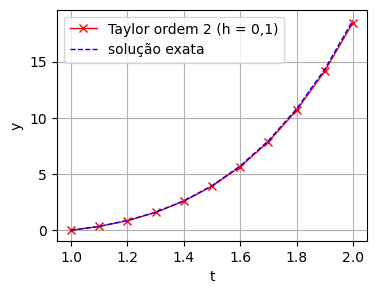

In [12]:
t0 = 1
tn = 2
N = 10

ti = np.linspace(t0, tn, N+1)
yi = np.zeros(len(ti))
y_exata = ti**2*(np.exp(ti) - np.exp(1))

f_num = sp.lambdify((t, y(t)), f_sym_h01, 'numpy')
for i in range(N):
    yi[i+1] = f_num(ti[i], yi[i])

tabela_erro(ti, yi, y_exata)

plt.plot(ti, yi, 'rx-', lw=1, label="Taylor ordem 2 (h = 0,1)")
plt.plot(ti, y_exata, 'b--', lw=1, label="solução exata")
plt.legend()
plt.grid()
plt.xlabel("t"); plt.ylabel("y")
plt.show()

### 6.2 Métodos de Runge-Kutta

O método de Runge-Kutta mais simples é o de ordem 1: coincide com o método de Euler, isto é, o método de Taylor de ordem 1 (visto no [Notebook 5](../Notebook%2005%20-%20M%C3%A9todo%20de%20Euler%20para%20EDOs%20de%201%C2%AA%20ordem/05_metodo_de_euler.ipynb)).

Considerando, novamente, o Problema de Valor Inicial (PVI) dado por

$$\begin{cases}
   y' = f(x,y) \\
   y(x_0)=y_0
  \end{cases}$$

apresentamos a seguir os métodos de Runge-Kutta de ordem 1 a 4. Todos evitam calcular derivadas de $f$: em vez disso, avaliam $f$ em pontos auxiliares $k_1, k_2, \dots$ dentro do passo $h$, combinados de forma a reproduzir a precisão do método de Taylor correspondente.

### Método de Runge-Kutta de ordem 1

$$ y_{n+1} =y_n + hk_1, \qquad k_1 = f(x_n, y_n)$$

### Método de Runge-Kutta de ordem 2

$$ y_{n+1} =y_n + \frac{h}{2}(k_1+k_2), \qquad k_1 = f(x_n, y_n), \quad k_2 = f(x_n+h, y_n+hk_1) $$

também conhecido como **método de Euler aperfeiçoado** ([Arenales e Darezzo, 2016](https://integrada.minhabiblioteca.com.br/reader/books/9788522112821/pageid/285)).

A figura abaixo ilustra uma interpretação gráfica do método.

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_III/refs/heads/main/Notebook%2006%20-%20M%C3%A9todos%20de%20Taylor%20e%20Runge-Kutta%20para%20EDOs%20de%201%C2%AA%20ordem/imagens/runge_kutta_ordem_2.png" width="600">

**Exemplo 6.3:** ([Fonte](https://integrada.minhabiblioteca.com.br/reader/books/9788522112821/pageid/287)) Usando o método de Euler aperfeiçoado, calcule a solução do PVI definido por:

$$\begin{cases}
   y' = f(x,y)=x-y+2 \\
   y(x_0)= y(0) = 2
  \end{cases}$$

com $x \in [a,b] = [0,1]$ e $N = 5$.

A solução exata é $y(x) = e^{-x}+x+1$.

  i        x_i     Y (aperf.)       y(x_i)         Erro
--------------------------------------------------------
  0     0.0000       2.000000     2.000000   0.0000e+00
  1     0.2000       2.020000     2.018731   1.2692e-03
  2     0.4000       2.072400     2.070320   2.0800e-03
  3     0.6000       2.151368     2.148812   2.5564e-03
  4     0.8000       2.252122     2.249329   2.7928e-03
  5     1.0000       2.370740     2.367879   2.8604e-03


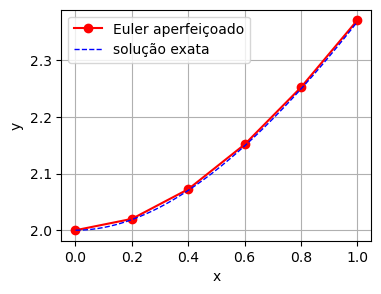

In [13]:
def rk2_aperfeicoado(f, x0, y0, h, N):
    """Método de Runge-Kutta de ordem 2 (Euler aperfeiçoado) para o PVI
    y' = f(x, y), y(x0) = y0. Retorna dois vetores (x, y) com N + 1 pontos.
    """
    x = np.zeros(N + 1); y = np.zeros(N + 1)
    x[0], y[0] = x0, y0
    for i in range(N):
        k1 = f(x[i], y[i])
        k2 = f(x[i] + h, y[i] + h*k1)
        y[i+1] = y[i] + h/2*(k1 + k2)
        x[i+1] = x[i] + h
    return x, y

f = lambda x, y: x - y + 2
sol_exata = lambda x: np.exp(-x) + x + 1

a, b, N = 0.0, 1.0, 5
h = (b - a)/N
X, Y = rk2_aperfeicoado(f, x0=0.0, y0=2.0, h=h, N=N)

tabela_erro(X, Y, sol_exata(X), nome="Y (aperf.)")

Xe = np.linspace(a, b, 200)
plt.plot(X, Y, 'ro-', label="Euler aperfeiçoado")
plt.plot(Xe, sol_exata(Xe), 'b--', lw=1, label="solução exata")
plt.legend(); plt.grid()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

Outra escolha de pontos auxiliares fornece uma segunda variante de método de Runge-Kutta de ordem 2, também bastante usada:

$$
y_{n+1}=y_n+h\, f\left(x_n+\frac{h}{2}, y_n+\frac{h}{2} k_1\right), \qquad k_1=f\left(x_n, y_n\right)
$$

conhecido como **método de Euler modificado** (ou método do ponto médio) ([Arenales e Darezzo, 2016](https://integrada.minhabiblioteca.com.br/reader/books/9788522112821/pageid/288)).

**Exemplo 6.4:** Usando o método de Euler modificado, calcule a solução do PVI definido por:

$$\begin{cases}
   y' = f(x,y)=x-y+2 \\
   y(x_0)= y(0) = 2
  \end{cases}$$

com $x \in [a,b] = [0,1]$ e $h=0,2$.

A solução exata é $y(x) = e^{-x}+x+1$.

  i        x_i     Y (modif.)       y(x_i)         Erro
--------------------------------------------------------
  0     0.0000       2.000000     2.000000   0.0000e+00
  1     0.2000       2.020000     2.018731   1.2692e-03
  2     0.4000       2.072400     2.070320   2.0800e-03
  3     0.6000       2.151368     2.148812   2.5564e-03
  4     0.8000       2.252122     2.249329   2.7928e-03
  5     1.0000       2.370740     2.367879   2.8604e-03


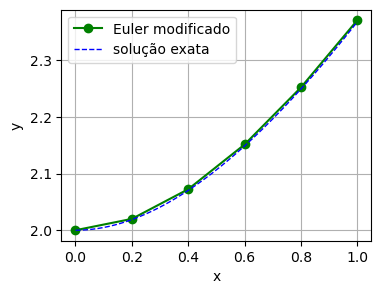

In [14]:
def rk2_modificado(f, x0, y0, h, N):
    """Método de Runge-Kutta de ordem 2 (Euler modificado / ponto médio)
    para o PVI y' = f(x, y), y(x0) = y0.
    """
    x = np.zeros(N + 1); y = np.zeros(N + 1)
    x[0], y[0] = x0, y0
    for i in range(N):
        k1 = f(x[i], y[i])
        y[i+1] = y[i] + h*f(x[i] + h/2, y[i] + h/2*k1)
        x[i+1] = x[i] + h
    return x, y

Xm, Ym = rk2_modificado(f, x0=0.0, y0=2.0, h=0.2, N=5)

tabela_erro(Xm, Ym, sol_exata(Xm), nome="Y (modif.)")

plt.plot(Xm, Ym, 'go-', label="Euler modificado")
plt.plot(Xe, sol_exata(Xe), 'b--', lw=1, label="solução exata")
plt.legend(); plt.grid()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

Comparando os valores de $Y$ dos Exemplos 6.3 e 6.4 com os obtidos pelo método de Taylor de ordem 2 no Exemplo 6.1: os três coincidem, casa decimal por casa decimal. Isso **não é coincidência**: para essa EDO, $f(x,y)=x-y+2$ é **afim** em $(x,y)$ (isto é, $f_{xx}=f_{xy}=f_{yy}=0$), e nesse caso todo método de Runge-Kutta de ordem 2 de dois estágios — qualquer que seja o ponto auxiliar escolhido — reproduz exatamente a fórmula de Taylor de ordem 2. Para uma EDO **não linear** em $y$, em geral os métodos diferem (embora ambos continuem sendo de ordem 2). Veja abaixo, para $y'=xy$, $y(0)=1$ (solução exata $y(x)=e^{x^2/2}$):

In [15]:
f_nl = lambda x, y: x*y
sol_nl = lambda x: np.exp(x**2/2)

Xa, Ya = rk2_aperfeicoado(f_nl, x0=0.0, y0=1.0, h=0.2, N=5)
Xm2, Ym2 = rk2_modificado(f_nl, x0=0.0, y0=1.0, h=0.2, N=5)

print(f"{'x_i':>6} {'aperf.':>12} {'modif.':>12} {'exata':>12}")
for i in range(len(Xa)):
    print(f"{Xa[i]:6.2f} {Ya[i]:12.6f} {Ym2[i]:12.6f} {sol_nl(Xa[i]):12.6f}")

   x_i       aperf.       modif.        exata
  0.00     1.000000     1.000000     1.000000
  0.20     1.020000     1.020000     1.020201
  0.40     1.082832     1.082424     1.083287
  0.60     1.196313     1.194996     1.197217
  0.80     1.375281     1.372334     1.377128
  1.00     1.644836     1.639115     1.648721


#### 6.2.1 Método de Runge-Kutta de ordem 3

$$ y_{n+1} =y_n + \frac{h}{9}(2k_1 + 3k_2 + 4k_3) $$

com

$$ k_1 = f(x_n , y_n),$$
$$k_2 = f(x_n + \tfrac{1}{2}h, y_n + \tfrac{1}{2}hk_1),$$
$$\qquad k_3 = f(x_n + \tfrac{3}{4}h, y_n + \tfrac{3}{4}hk_2).$$

([Arenales e Darezzo, 2016](https://integrada.minhabiblioteca.com.br/reader/books/9788522112821/pageid/291))

**Exemplo 6.5:** Usando o método de Runge-Kutta de ordem 3, calcule a solução do PVI definido por:

$$\begin{cases}
   y' = f(x,y)=x-y+2 \\
   y(x_0)= y(0) = 2
  \end{cases}$$

com $x \in [a,b] = [0,1]$ e $h=0,2$.

A solução exata é $y(x) = e^{-x}+x+1$.

  i        x_i        Y (RK3)       y(x_i)         Erro
--------------------------------------------------------
  0     0.0000       2.000000     2.000000   0.0000e+00
  1     0.2000       2.018667     2.018731   6.4086e-05
  2     0.4000       2.070215     2.070320   1.0493e-04
  3     0.6000       2.148683     2.148812   1.2887e-04
  4     0.8000       2.249188     2.249329   1.4067e-04
  5     1.0000       2.367735     2.367879   1.4396e-04


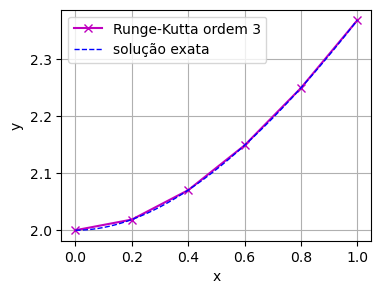

In [16]:
def rk3(f, x0, y0, h, N):
    """Método de Runge-Kutta de ordem 3 para o PVI y' = f(x, y), y(x0) = y0."""
    x = np.zeros(N + 1); y = np.zeros(N + 1)
    x[0], y[0] = x0, y0
    for i in range(N):
        k1 = f(x[i], y[i])
        k2 = f(x[i] + 0.5*h, y[i] + 0.5*h*k1)
        k3 = f(x[i] + 0.75*h, y[i] + 0.75*h*k2)
        y[i+1] = y[i] + (h/9)*(2*k1 + 3*k2 + 4*k3)
        x[i+1] = x[i] + h
    return x, y

X3, Y3 = rk3(f, x0=0.0, y0=2.0, h=0.2, N=5)

tabela_erro(X3, Y3, sol_exata(X3), nome="Y (RK3)")

plt.plot(X3, Y3, 'mx-', label="Runge-Kutta ordem 3")
plt.plot(Xe, sol_exata(Xe), 'b--', lw=1, label="solução exata")
plt.legend(); plt.grid()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

#### 6.2.2 Método de Runge-Kutta de ordem 4

$$ y_{n+1} =y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4) $$

com

$$k_1 = f(x_n , y_n),$$
$$k_2 = f(x_n + \tfrac{1}{2}h, y_n + \tfrac{1}{2}hk_1),$$
$$k_3 = f(x_n + \tfrac{1}{2}h, y_n + \tfrac{1}{2}hk_2),$$
$$k_4 = f(x_n + h, y_n + hk_3)$$

**Exemplo 6.6:** Usando o método de Runge-Kutta de ordem 4, calcule a solução do PVI definido por:

$$\begin{cases}
   y' = f(x,y)=x-y+2 \\
   y(x_0)= y(0) = 2
  \end{cases}$$

com $x \in [a,b] = [0,1]$ e $h=0,2$.

A solução exata é $y(x) = e^{-x}+x+1$.

  i        x_i        Y (RK4)       y(x_i)         Erro
--------------------------------------------------------
  0     0.0000       2.000000     2.000000   0.0000e+00
  1     0.2000       2.018733     2.018731   2.5803e-06
  2     0.4000       2.070324     2.070320   4.2251e-06
  3     0.6000       2.148817     2.148812   5.1888e-06
  4     0.8000       2.249335     2.249329   5.6643e-06
  5     1.0000       2.367885     2.367879   5.7970e-06


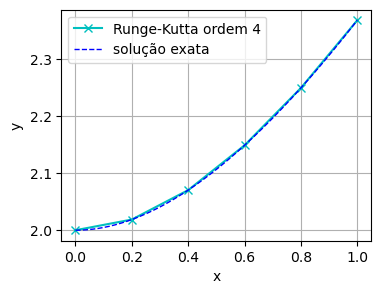

In [17]:
def rk4(f, x0, y0, h, N):
    """Método de Runge-Kutta de ordem 4 (clássico) para o PVI
    y' = f(x, y), y(x0) = y0.
    """
    x = np.zeros(N + 1); y = np.zeros(N + 1)
    x[0], y[0] = x0, y0
    for i in range(N):
        k1 = f(x[i], y[i])
        k2 = f(x[i] + 0.5*h, y[i] + 0.5*h*k1)
        k3 = f(x[i] + 0.5*h, y[i] + 0.5*h*k2)
        k4 = f(x[i] + h, y[i] + h*k3)
        y[i+1] = y[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        x[i+1] = x[i] + h
    return x, y

X4, Y4 = rk4(f, x0=0.0, y0=2.0, h=0.2, N=5)

tabela_erro(X4, Y4, sol_exata(X4), nome="Y (RK4)")

plt.plot(X4, Y4, 'cx-', label="Runge-Kutta ordem 4")
plt.plot(Xe, sol_exata(Xe), 'b--', lw=1, label="solução exata")
plt.legend(); plt.grid()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

#### Atividade 6.2

Aplique `rk2_aperfeicoado`, `rk3` e `rk4` ao PVI $y'=xy$, $y(0)=1$ em $[0,1]$ (solução exata $y(x)=e^{x^2/2}$, já usado acima) com $h=0,1$. Monte uma tabela comparando o erro final dos três métodos.

### 6.3 Comparando a ordem dos métodos

Cada método tem uma ordem $p$ de convergência: o erro global se comporta como $O(h^p)$. Isso significa que, ao reduzir o passo $h$ à metade, o erro final deve cair, aproximadamente, por um fator $2^p$. Vamos confirmar isso para o PVI dos Exemplos 6.1–6.6, comparando Euler ($p=1$), Taylor 2 / RK2 ($p=2$), RK3 ($p=3$) e RK4 ($p=4$).

In [18]:
def euler(f, x0, y0, h, N):
    """Método de Euler (visto no Notebook 5) — incluído aqui só para comparação."""
    x = np.zeros(N + 1); y = np.zeros(N + 1)
    x[0], y[0] = x0, y0
    for i in range(N):
        y[i+1] = y[i] + h*f(x[i], y[i])
        x[i+1] = x[i] + h
    return x, y

metodos = {
    "Euler   (p=1)": euler,
    "RK2     (p=2)": rk2_aperfeicoado,
    "RK3     (p=3)": rk3,
    "RK4     (p=4)": rk4,
}

hs = np.array([0.2, 0.1, 0.05, 0.025, 0.0125])
erros = {nome: np.zeros(len(hs)) for nome in metodos}

for nome, metodo in metodos.items():
    for k, h in enumerate(hs):
        N = round(1.0/h)
        X, Y = metodo(f, 0.0, 2.0, h, N)
        erros[nome][k] = abs(Y[-1] - sol_exata(X[-1]))

print(f"{'h':>8}", *[f"{nome:>16}" for nome in metodos])
for k, h in enumerate(hs):
    print(f"{h:8.4f}", *[f"{erros[nome][k]:16.4e}" for nome in metodos])

print("\nrazão entre erros sucessivos (h dividido por 2):")
print(f"{'':>8}", *[f"{nome:>16}" for nome in metodos])
for k in range(1, len(hs)):
    print(f"{hs[k-1]:>4.3f}->{hs[k]:<4.3f}", *[f"{erros[nome][k-1]/erros[nome][k]:16.3f}" for nome in metodos])

       h    Euler   (p=1)    RK2     (p=2)    RK3     (p=3)    RK4     (p=4)
  0.2000       4.0199e-02       2.8604e-03       1.4396e-04       5.7970e-06
  0.1000       1.9201e-02       6.6154e-04       1.6607e-05       3.3324e-07
  0.0500       9.3935e-03       1.5918e-04       1.9943e-06       1.9976e-08
  0.0250       4.6470e-03       3.9049e-05       2.4435e-07       1.2227e-09
  0.0125       2.3113e-03       9.6706e-06       3.0239e-08       7.5629e-11

razão entre erros sucessivos (h dividido por 2):
            Euler   (p=1)    RK2     (p=2)    RK3     (p=3)    RK4     (p=4)
0.200->0.100            2.094            4.324            8.669           17.396
0.100->0.050            2.044            4.156            8.327           16.682
0.050->0.025            2.021            4.076            8.162           16.337
0.025->0.013            2.011            4.038            8.080           16.168


As razões se aproximam de $2$, $4$, $8$ e $16$ — ou seja, $2^p$ para $p=1,2,3,4$ — confirmando a ordem de cada método. No gráfico log-log a seguir, cada método aparece como uma reta cuja inclinação é a sua ordem $p$.

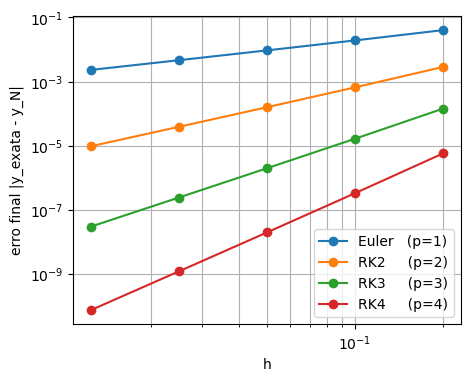

In [19]:
plt.figure(figsize=(5,4))
for nome in metodos:
    plt.loglog(hs, erros[nome], 'o-', label=nome)
plt.xlabel("h"); plt.ylabel("erro final |y_exata - y_N|")
plt.legend()
plt.grid(True, which="both")
plt.show()

### 6.4 Solução numérica com SciPy

Como já vimos, a biblioteca `scipy` implementa alguns algoritmos numéricos para soluções de PVIs em `solve_ivp`. O método padrão, `RK45`, é uma variante de Runge-Kutta de ordem 4(5) com **passo adaptativo**: a cada passo o próprio algoritmo estima o erro local e ajusta $h$ automaticamente, usando passos maiores onde a solução varia pouco e passos menores onde ela varia rápido — diferente dos métodos acima, em que fixamos um único $h$ para todo o intervalo. Vamos usar para esse mesmo problema.

In [20]:
from scipy.integrate import solve_ivp

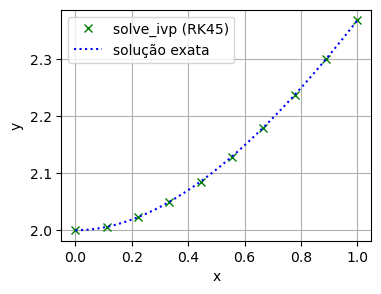

In [21]:
sol = solve_ivp(f, [0, 1], [2],
                method="RK45",  # Runge-Kutta de ordem 5(4), passo adaptativo
                t_eval=np.linspace(0, 1, 10))

plt.plot(sol.t, sol.y[0], 'gx', label="solve_ivp (RK45)")
plt.plot(Xe, sol_exata(Xe), 'b:', label="solução exata")
plt.legend(); plt.grid()
plt.xlabel("x"); plt.ylabel("y")
plt.show()

### 6.5 Exercícios

**1.** ([Fonte](https://integrada.minhabiblioteca.com.br/reader/books/9788522123414/pageid/324)) Dado o problema de valor inicial

$$
y^{\prime}=\frac{1}{t^2}-\frac{y}{t}-y^2, \quad 1 \leq t \leq 2, \quad y(1)=-1
$$

com solução exata $y(t)=-1 / t$ :

(a) Use o método de Taylor de segunda ordem com $h=0,05$ para encontrar uma aproximação da solução e compare-a com os valores reais de $y$.

(b) Use o método de Taylor de quarta ordem com $h=0,05$ para aproximar a solução e compare-a com os valores reais de $y$. (Use `taylor_formula(dy, t, y, 4)`, da Seção 6.1.1.)

**2.** Use o método de Taylor de segunda ordem para encontrar uma aproximação das soluções de cada um dos seguintes problemas de valor inicial. Se possível, obtenha a solução exata e compare.

(a) $y^{\prime}=y / t-(y / t)^2, \quad 1 \leq t \leq 1,2, \quad y(1)=1, \quad \operatorname{com} h=0,1$

(b) $y^{\prime}=\operatorname{sen} t+e^{-t}, \quad 0 \leq t \leq 1, \quad y(0)=0, \quad \operatorname{com} h=0,5$

(c) $y^{\prime}=\left(y^2+y\right) / t, \quad 1 \leq t \leq 3, \quad y(1)=-2, \quad \operatorname{com} h=0,5$

(d) $y^{\prime}=-t y+4 t y^{-1}, \quad 0 \leq t \leq 1, \quad y(0)=1, \quad \operatorname{com} h=0,25$

**3.** Use o método de Taylor de segunda ordem para encontrar uma aproximação das soluções de cada um dos seguintes problemas de valor inicial. Se possível, obtenha a solução exata e compare.

(a) $y^{\prime}=\frac{2-2 t y}{t^2+1}, \quad 0 \leq t \leq 1, \quad y(0)=1, \operatorname{com} h=0,1$

(b) $y^{\prime}=\frac{y^2}{1+t}, \quad 1 \leq t \leq 2, \quad y(1)=-(\ln 2)^{-1}, \operatorname{com} h=0,1$

(c) $y^{\prime}=\left(y^2+y\right) / t, \quad 1 \leq t \leq 3, \quad y(1)=-2, \quad$ com $h=0,2$

(d) $y^{\prime}=-t y+4 t / y, \quad 0 \leq t \leq 1, \quad y(0)=1, \quad \operatorname{com} h=0,1$

**4.** Repita o Exercício 3 usando o método de Taylor de quarta ordem.

**5.** Repita o Exercício 2 usando o método de Taylor de quarta ordem.

**Referências**

ARENALES, Selma; DAREZZO, Artur. Cálculo Numérico: aprendizagem com Apoio de Software. Porto Alegre: Cengage Learning Brasil, 2016.

BURDEN, Richard L.; FAIRES, J D.; BURDEN, Annette M. Análise Numérica - Tradução da 10ª edição norte-americana. 3. ed. Porto Alegre: +A Educação - Cengage Learning Brasil, 2016.